In [1]:
# ImportLibraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [2]:
# Add the dataset to collab

filepath = "/kaggle/input/datasets/arnoldaijuka/public-country-lyrics-amazing-spreadsheet/PUBLIC_Country_Lyrics_Amazing_Spreadsheet.xlsx"

df = pd.read_excel(filepath)

# Display the total number of rows and columns of the dataset
print(f'The shape of the dataset is {df.shape[0]} rows and {df.shape[1]} columns')

The shape of the dataset is 484 rows and 10 columns


In [3]:
df.sample(5)

,Song,Artist,Featuring,Entered Top 30 In:,Lyrics,Writers,Producer,Rough Order,Unnamed: 8,RULES!!!! Top 30 Country Airplay From March 2014-March 2017
407,Make It Sweet,Old Dominion,NaN,2018,"I know it's a drag, I know it's a grind I know...","Matthew Ramsey, Trevor Rosen, Whit Sellers, Ge...",Shane McAnally,408,NaN,NaN
209,I Met A Girl,William Michael Morgan,NaN,2016,She don't laugh at everything But when she doe...,"Sam Hunt, Trevor Rosen, Shane McAnally","Jimmy Ritchey, Scott Hendricks",210,NaN,NaN
331,For The First Time,Darius Rucker,NaN,2017,You say you never danced to a dashboard singin...,"Darius Rucker, Derek George, Scooter Carusoe",Ross Copperman,332,NaN,NaN
161,Little Bit of You,Chase Bryant,NaN,2015,I hope that I ain't callin' too late baby Hope...,"Chase Bryant, Derek George, Ashley Gorley",Derek George,162,NaN,NaN
118,Sippin' On Fire,Florida Georgia Line,NaN,2015,"Girl, you melt me like ice in whiskey With tho...","Rodney Clawson, Matt Dragstrem, Cole Taylor",Joey Moi,119,NaN,NaN


In [4]:
# Check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 10 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Song                                                         484 non-null    object 
 1   Artist                                                       484 non-null    object 
 2   Featuring                                                    42 non-null     object 
 3   Entered Top 30 In:                                           484 non-null    int64  
 4   Lyrics                                                       484 non-null    object 
 5   Writers                                                      484 non-null    object 
 6   Producer                                                     482 non-null    object 
 7   Rough Order                                                  484 non-null    int

In [5]:
# Drop completely empty unused columns
df = df.drop(columns=['Unnamed: 8', 'RULES!!!! Top 30 Country Airplay From March 2014-March 2017'])

In [6]:
# Check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Song                484 non-null    object
 1   Artist              484 non-null    object
 2   Featuring           42 non-null     object
 3   Entered Top 30 In:  484 non-null    int64 
 4   Lyrics              484 non-null    object
 5   Writers             484 non-null    object
 6   Producer            482 non-null    object
 7   Rough Order         484 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 30.4+ KB


In [7]:
# Determine most popular artist for each year
most_popular_df = df.groupby('Entered Top 30 In:')['Artist'].agg(pd.Series.mode).to_frame()
most_popular_df.head()

,Artist
Entered Top 30 In:,
2013,"[Brett Eldredge, Cole Swindell, Craig Morgan, ..."
2014,"[Blake Shelton, Florida Georgia Line]"
2015,Luke Bryan
2016,"[Blake Shelton, Dierks Bentley, Jason Aldean, ..."
2017,Thomas Rhett


## Top Songwriters

In [8]:
# Determine most popular songwriter

# Split writer column into its own dataset
writers = df['Writers']

# Split the writers into their own columns instead of having comma's (We will use .explode()) (we also need to convert it to string)
writers = writers.str.split(',').explode()

# Remove whitespace
writers = writers.str.strip()

# Remove any completely empty strings that might have resulted from trailing commas
cleaned_writers = writers[writers != ""]

writers_counts = cleaned_writers.value_counts()

# Create a new DataFrame with the counts
writers_counts.head(5)


Writers
Ashley Gorley     44
Shane McAnally    36
Ross Copperman    32
Josh Osborne      29
Rhett Akins       23
Name: count, dtype: int64

/tmp/ipykernel_16/2157111495.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_writers.index, y=top_5_writers.values, palette="pastel")


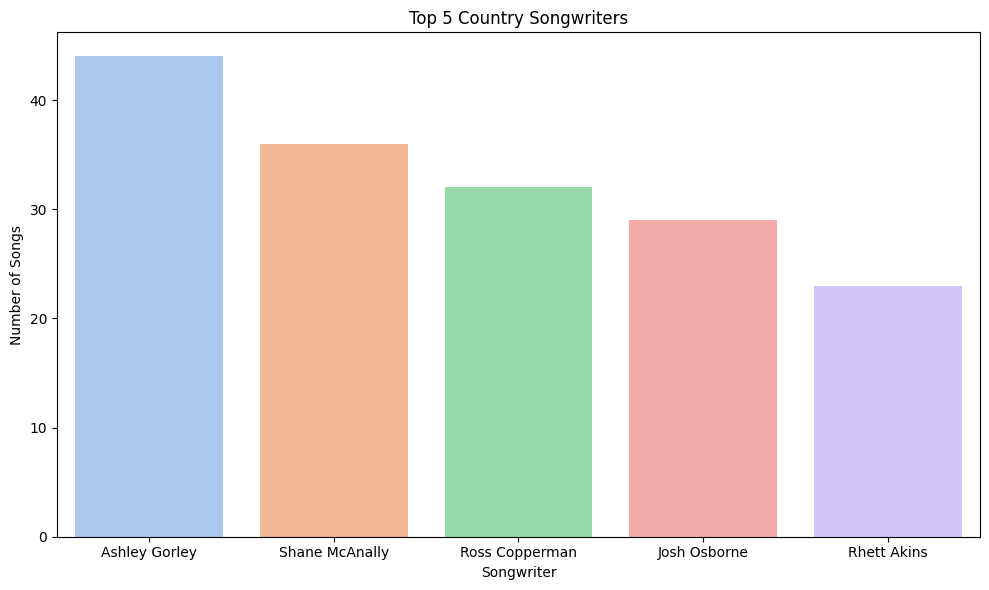

In [9]:
# Visualize the top writers

# Extract just the names of the top 5 writers
top_5_writers = writers_counts.head(5)

# Countplot for Writers
# Set the size of the figure
plt.figure(figsize=(10, 6))

# Create the countplot
sns.barplot(x=top_5_writers.index, y=top_5_writers.values, palette="pastel")

# Add labels and title
plt.title("Top 5 Country Songwriters")
plt.xlabel("Songwriter")
plt.ylabel("Number of Songs")

# Adjust layout to fit everything and display the plot
plt.tight_layout()
plt.show()

## Top Artists

In [10]:
# Determine most popular artists

# Split writer column into its own dataset
artists = df['Artist']

# Remove whitespace
artists = artists.str.strip()

artists_counts = artists.value_counts()

# Create a new DataFrame with the counts
artists_counts.head(5)

Artist
Luke Bryan              16
Blake Shelton           15
Thomas Rhett            14
Jason Aldean            14
Florida Georgia Line    13
Name: count, dtype: int64

/tmp/ipykernel_16/608952235.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_artists.index, y=top_5_artists.values, palette="pastel")


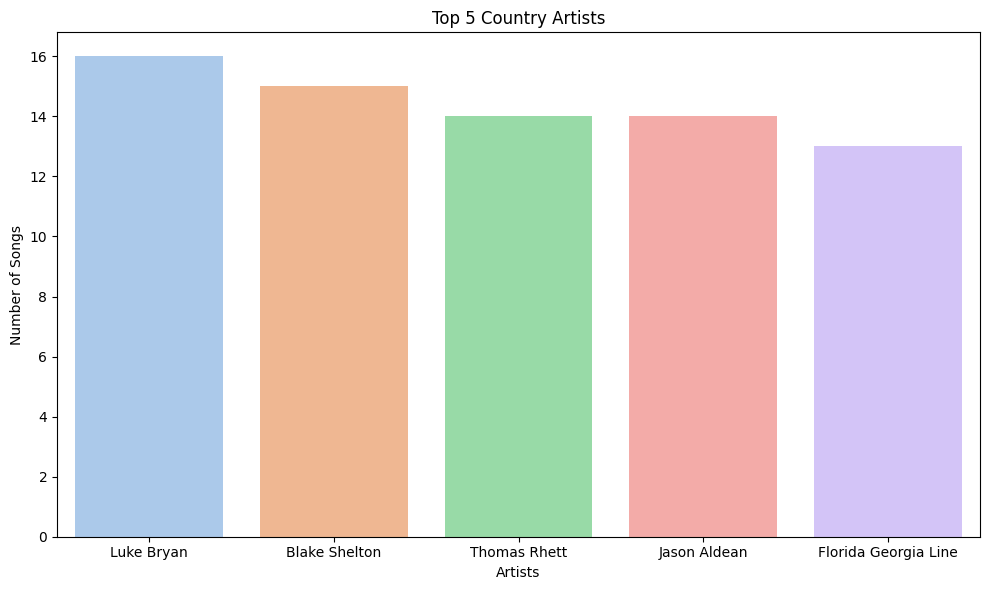

In [11]:
# Visualize the top writers

# Extract just the names of the top 5 writers
top_5_artists = artists_counts.head(5)

# Countplot for Writers
# Set the size of the figure
plt.figure(figsize=(10, 6))

# Create the countplot
sns.barplot(x=top_5_artists.index, y=top_5_artists.values, palette="pastel")

# Add labels and title
plt.title("Top 5 Country Artists")
plt.xlabel("Artists")
plt.ylabel("Number of Songs")

# Adjust layout to fit everything and display the plot
plt.tight_layout()
plt.show()

## Top Producers

In [12]:
# Determine most producer songwriter

# Split writer column into its own dataset
producers = df['Producer']

# Split the writers into their own columns instead of having comma's (We will use .explode()) (we also need to convert it to string)
producers = producers.str.split(',').explode()

# Remove whitespace
producers = producers.str.strip()

# Remove any completely empty strings that might have resulted from trailing commas
cleaned_producers= producers[producers != ""]

producers_counts = cleaned_producers.value_counts()

# Create a new DataFrame with the counts
producers_counts.head(5)


Producer
Dann Huff          59
Scott Hendricks    33
Jay Joyce          28
Joey Moi           28
Ross Copperman     26
Name: count, dtype: int64

/tmp/ipykernel_16/1331848279.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_producers.index, y=top_5_producers.values, palette="pastel")


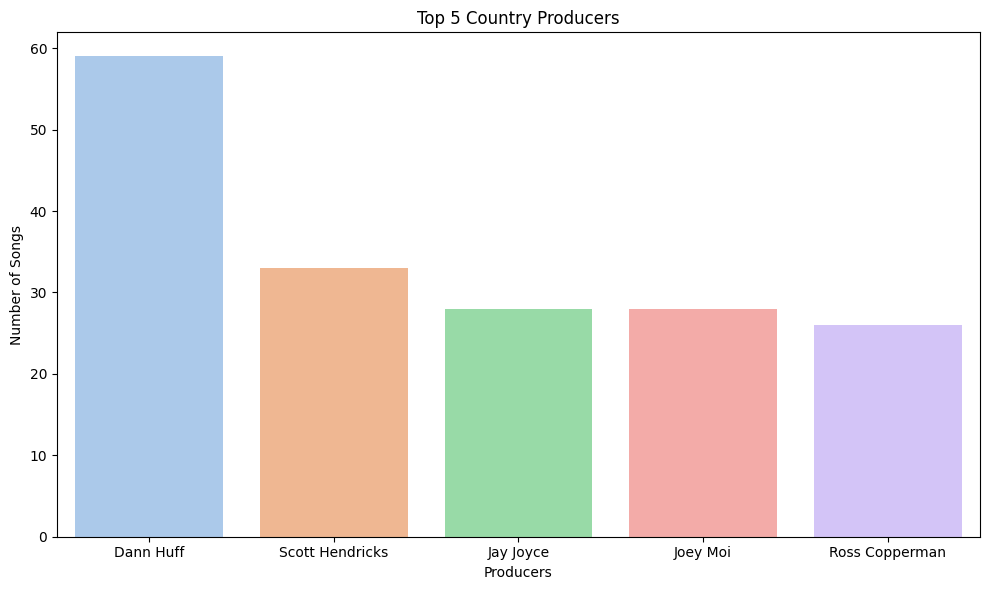

In [13]:
# Visualize the top writers

# Extract just the names of the top 5 writers
top_5_producers = producers_counts.head(5)

# Countplot for Writers
# Set the size of the figure
plt.figure(figsize=(10, 6))

# Create the countplot
sns.barplot(x=top_5_producers.index, y=top_5_producers.values, palette="pastel")

# Add labels and title
plt.title("Top 5 Country Producers")
plt.xlabel("Producers")
plt.ylabel("Number of Songs")

# Adjust layout to fit everything and display the plot
plt.tight_layout()
plt.show()